1) First, let's import necessary libraries and load all datasets:

In [102]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Date handling
from datetime import datetime, timedelta

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [103]:
# File list
files = [
    "Sale_012025.csv",
    "Sale_022025.csv",
    "Sale_032025.csv",
    "Sale_042025.csv",
    "Sale_052025.csv",
    "Sale_062025.csv",
    "Sale_072025.csv",
    "Sale_082024.csv",
    "Sale_092024.csv",
    "Sale_102024.csv",
    "Sale_112024.csv",
    "Sale_122024.csv",
]

# Load and combine all files
df_list = []
for file in files:
    try:
        temp_df = pd.read_csv(file)
        df_list.append(temp_df)
        print(f"✓ Loaded {file}: {len(temp_df):,} rows")
    except Exception as e:
        print(f"✗ Error loading {file}: {e}")

# Combine all dataframes
df = pd.concat(df_list, ignore_index=True)

print(f"\n{'='*60}")
print(f"Total records loaded: {len(df):,}")
print(f"{'='*60}")

✓ Loaded Sale_012025.csv: 804,907 rows
✓ Loaded Sale_022025.csv: 784,248 rows
✓ Loaded Sale_032025.csv: 793,216 rows
✓ Loaded Sale_042025.csv: 835,898 rows
✓ Loaded Sale_052025.csv: 871,432 rows
✓ Loaded Sale_062025.csv: 787,168 rows
✓ Loaded Sale_072025.csv: 975,438 rows
✓ Loaded Sale_082024.csv: 1,009,231 rows
✓ Loaded Sale_092024.csv: 910,781 rows
✓ Loaded Sale_102024.csv: 977,458 rows
✓ Loaded Sale_112024.csv: 900,332 rows
✓ Loaded Sale_122024.csv: 891,684 rows

Total records loaded: 10,541,793


In [104]:
# Display initial data info
print("INITIAL DATA OVERVIEW")
print("="*60)
df.info()

INITIAL DATA OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10541793 entries, 0 to 10541792
Data columns (total 10 columns):
 #   Column        Dtype  
---  ------        -----  
 0   SaleId        int64  
 1   ProcessDate   object 
 2   ClientId      int64  
 3   GpsLatitude   float64
 4   GpsLongitude  float64
 5   SalesmanRef   float64
 6   ItemId        int64  
 7   Quantity      float64
 8   Price         float64
 9   ItemUnitCode  object 
dtypes: float64(5), int64(3), object(2)
memory usage: 804.3+ MB


In [105]:
df.head(15)

,SaleId,ProcessDate,ClientId,GpsLatitude,GpsLongitude,SalesmanRef,ItemId,Quantity,Price,ItemUnitCode
0,8536594,1/3/2025,1000005017,0.00,0.00,31524.00,6655,2.00,64.82,QTU
1,8536594,1/3/2025,1000005017,0.00,0.00,31524.00,1401,2.00,64.82,QTU
2,8536594,1/3/2025,1000005017,0.00,0.00,31524.00,1402,2.00,64.82,QTU
3,8536594,1/3/2025,1000005017,0.00,0.00,31524.00,237293,2.00,64.82,QTU
4,8536594,1/3/2025,1000005017,0.00,0.00,31524.00,237292,2.00,64.82,QTU
5,8536594,1/3/2025,1000005017,0.00,0.00,31524.00,237298,2.00,91.30,QTU
6,8536594,1/3/2025,1000005017,0.00,0.00,31524.00,7138,2.00,91.30,QTU
7,8536594,1/3/2025,1000005017,0.00,0.00,31524.00,7137,2.00,91.30,QTU
8,8536605,1/3/2025,1000005119,0.00,0.00,31524.00,4954,1.00,30.40,QTU
9,8536605,1/3/2025,1000005119,0.00,0.00,31524.00,3451,1.00,11.70,QTU


In [106]:
# Convert ProcessDate to datetime
df['ProcessDate'] = pd.to_datetime(df['ProcessDate'])

# Create additional time-based features
df['Day'] = df['ProcessDate'].dt.day
df['WeekOfYear'] = df['ProcessDate'].dt.isocalendar().week
df['Month'] = df['ProcessDate'].dt.month
df['Year'] = df['ProcessDate'].dt.year

# Sort by date
df = df.sort_values('ProcessDate').reset_index(drop=True)

print("✓ Date features created")
print(f"Date range: {df['ProcessDate'].min()} to {df['ProcessDate'].max()}")

✓ Date features created
Date range: 2024-07-01 00:00:00 to 2025-06-26 00:00:00


In [107]:
df.head(20)

,SaleId,ProcessDate,ClientId,GpsLatitude,GpsLongitude,SalesmanRef,ItemId,Quantity,Price,ItemUnitCode,Day,WeekOfYear,Month,Year
0,7276392,2024-07-01,1000001367,0.00,0.00,11570.00,6935,12.00,2.63,ADT,1,27,7,2024
1,7276365,2024-07-01,1000003809,0.00,0.00,13884.00,32130,10.00,1.85,ADT,1,27,7,2024
2,7276365,2024-07-01,1000003809,0.00,0.00,13884.00,9270,10.00,2.30,ADT,1,27,7,2024
3,7276365,2024-07-01,1000003809,0.00,0.00,13884.00,9268,10.00,1.85,ADT,1,27,7,2024
4,7276369,2024-07-01,1000004111,0.00,0.00,11058.00,303064,1.00,47.76,QTU,1,27,7,2024
5,7276369,2024-07-01,1000004111,0.00,0.00,11058.00,303066,1.00,47.76,QTU,1,27,7,2024
6,7276369,2024-07-01,1000004111,0.00,0.00,11058.00,303063,1.00,47.76,QTU,1,27,7,2024
7,7276369,2024-07-01,1000004111,0.00,0.00,11058.00,303065,1.00,47.76,QTU,1,27,7,2024
8,7276369,2024-07-01,1000004111,0.00,0.00,11058.00,7897,1.00,47.76,QTU,1,27,7,2024
9,7276369,2024-07-01,1000004111,0.00,0.00,11058.00,8080,1.00,78.00,QTU,1,27,7,2024


In [108]:
print("DATA QUALITY ASSESSMENT")
print("="*60)

# Missing values
print("\n1. Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Duplicates
print(f"\n2. Duplicate Rows: {df.duplicated().sum():,}")


# Negative values check
print(f"\n4. Negative Quantities: {(df['Quantity'] < 0).sum():,}")
print(f"   Negative Prices: {(df['Price'] < 0).sum():,}")

# Outliers check (basic)
print("\n5. Potential Outliers (values beyond 99.9th percentile):")
print(f"   Quantity > {df['Quantity'].quantile(0.999):.0f}: {(df['Quantity'] > df['Quantity'].quantile(0.999)).sum():,}")
print(f"   Price > {df['Price'].quantile(0.999):.2f}: {(df['Price'] > df['Price'].quantile(0.999)).sum():,}")

DATA QUALITY ASSESSMENT

1. Missing Values:
             Missing Count  Percentage
SalesmanRef            221        0.00

2. Duplicate Rows: 34

4. Negative Quantities: 0
   Negative Prices: 0

5. Potential Outliers (values beyond 99.9th percentile):
   Quantity > 600: 9,789
   Price > 386.40: 10,378


In [109]:
df = df.drop(columns=["GpsLatitude", "GpsLongitude", "SalesmanRef"])
df = df.drop_duplicates()
df = df.reset_index(drop=True)

In [110]:
df.head(20)

,SaleId,ProcessDate,ClientId,ItemId,Quantity,Price,ItemUnitCode,Day,WeekOfYear,Month,Year
0,7276392,2024-07-01,1000001367,6935,12.00,2.63,ADT,1,27,7,2024
1,7276365,2024-07-01,1000003809,32130,10.00,1.85,ADT,1,27,7,2024
2,7276365,2024-07-01,1000003809,9270,10.00,2.30,ADT,1,27,7,2024
3,7276365,2024-07-01,1000003809,9268,10.00,1.85,ADT,1,27,7,2024
4,7276369,2024-07-01,1000004111,303064,1.00,47.76,QTU,1,27,7,2024
5,7276369,2024-07-01,1000004111,303066,1.00,47.76,QTU,1,27,7,2024
6,7276369,2024-07-01,1000004111,303063,1.00,47.76,QTU,1,27,7,2024
7,7276369,2024-07-01,1000004111,303065,1.00,47.76,QTU,1,27,7,2024
8,7276369,2024-07-01,1000004111,7897,1.00,47.76,QTU,1,27,7,2024
9,7276369,2024-07-01,1000004111,8080,1.00,78.00,QTU,1,27,7,2024


In [111]:
df.shape

(10541759, 11)

In [112]:
print("\nNumerical Columns:")
df[['Quantity', 'Price']].describe()


Numerical Columns:


,Quantity,Price
count,10541759.00,10541759.00
mean,11.24,20.10
std,150.00,30.25
min,1.00,0.00
25%,1.00,3.07
50%,3.00,12.24
75%,6.00,24.00
max,100000.00,1836.19


In [113]:
df_zero_price = df[df["Price"] == 0]
df_zero_price.shape[0]
df_zero_price

,SaleId,ProcessDate,ClientId,ItemId,Quantity,Price,ItemUnitCode,Day,WeekOfYear,Month,Year
7249931,8915830,2025-02-28,200003030,311115,1.00,0.00,ADT,28,9,2,2025
7250790,8915812,2025-02-28,200003030,311115,1.00,0.00,ADT,28,9,2,2025


In [114]:
df = df[df["Price"] > 0]

In [115]:
print("\nNumerical Columns:")
df[['Quantity', 'Price']].describe()


Numerical Columns:


,Quantity,Price
count,10541757.00,10541757.00
mean,11.24,20.10
std,150.00,30.25
min,1.00,0.05
25%,1.00,3.07
50%,3.00,12.24
75%,6.00,24.00
max,100000.00,1836.19


In [116]:
# Categorical analysis
print("\n\nCategorical Analysis:")
print(f"Unique Clients: {df['ClientId'].nunique():,}")
print(f"Unique Items: {df['ItemId'].nunique():,}")
print(f"Unique Sales Transactions: {df['SaleId'].nunique():,}")
print(f"Unique Unit Codes: {df['ItemUnitCode'].nunique()}")
print(f"Unit Code Types: {df['ItemUnitCode'].unique()}")



Categorical Analysis:
Unique Clients: 9,934
Unique Items: 4,427
Unique Sales Transactions: 1,443,091
Unique Unit Codes: 4
Unit Code Types: ['ADT' 'QTU' 'BLK' 'KL']


In [117]:
# Records per transaction
items_per_transaction = df.groupby('SaleId').size()
print(f"\n6. TRANSACTION STRUCTURE:")
print(f"   Average items per transaction: {items_per_transaction.mean():.2f}")
print(f"   Max items in a transaction: {items_per_transaction.max()}")
print(f"   Min items in a transaction: {items_per_transaction.min()}")


6. TRANSACTION STRUCTURE:
   Average items per transaction: 7.30
   Max items in a transaction: 40
   Min items in a transaction: 1


In [118]:
df.head()

,SaleId,ProcessDate,ClientId,ItemId,Quantity,Price,ItemUnitCode,Day,WeekOfYear,Month,Year
0,7276392,2024-07-01,1000001367,6935,12.00,2.63,ADT,1,27,7,2024
1,7276365,2024-07-01,1000003809,32130,10.00,1.85,ADT,1,27,7,2024
2,7276365,2024-07-01,1000003809,9270,10.00,2.30,ADT,1,27,7,2024
3,7276365,2024-07-01,1000003809,9268,10.00,1.85,ADT,1,27,7,2024
4,7276369,2024-07-01,1000004111,303064,1.00,47.76,QTU,1,27,7,2024


In [136]:
data = df.copy()
data.head()

,SaleId,ProcessDate,ClientId,ItemId,Quantity,Price,ItemUnitCode,Day,WeekOfYear,Month,Year
0,7276392,2024-07-01,1000001367,6935,12.00,2.63,ADT,1,27,7,2024
1,7276365,2024-07-01,1000003809,32130,10.00,1.85,ADT,1,27,7,2024
2,7276365,2024-07-01,1000003809,9270,10.00,2.30,ADT,1,27,7,2024
3,7276365,2024-07-01,1000003809,9268,10.00,1.85,ADT,1,27,7,2024
4,7276369,2024-07-01,1000004111,303064,1.00,47.76,QTU,1,27,7,2024


In [138]:
data = data.rename(columns={"Price": "Revenue"})
data.head()

,SaleId,ProcessDate,ClientId,ItemId,Quantity,Revenue,ItemUnitCode,Day,WeekOfYear,Month,Year
0,7276392,2024-07-01,1000001367,6935,12.00,2.63,ADT,1,27,7,2024
1,7276365,2024-07-01,1000003809,32130,10.00,1.85,ADT,1,27,7,2024
2,7276365,2024-07-01,1000003809,9270,10.00,2.30,ADT,1,27,7,2024
3,7276365,2024-07-01,1000003809,9268,10.00,1.85,ADT,1,27,7,2024
4,7276369,2024-07-01,1000004111,303064,1.00,47.76,QTU,1,27,7,2024


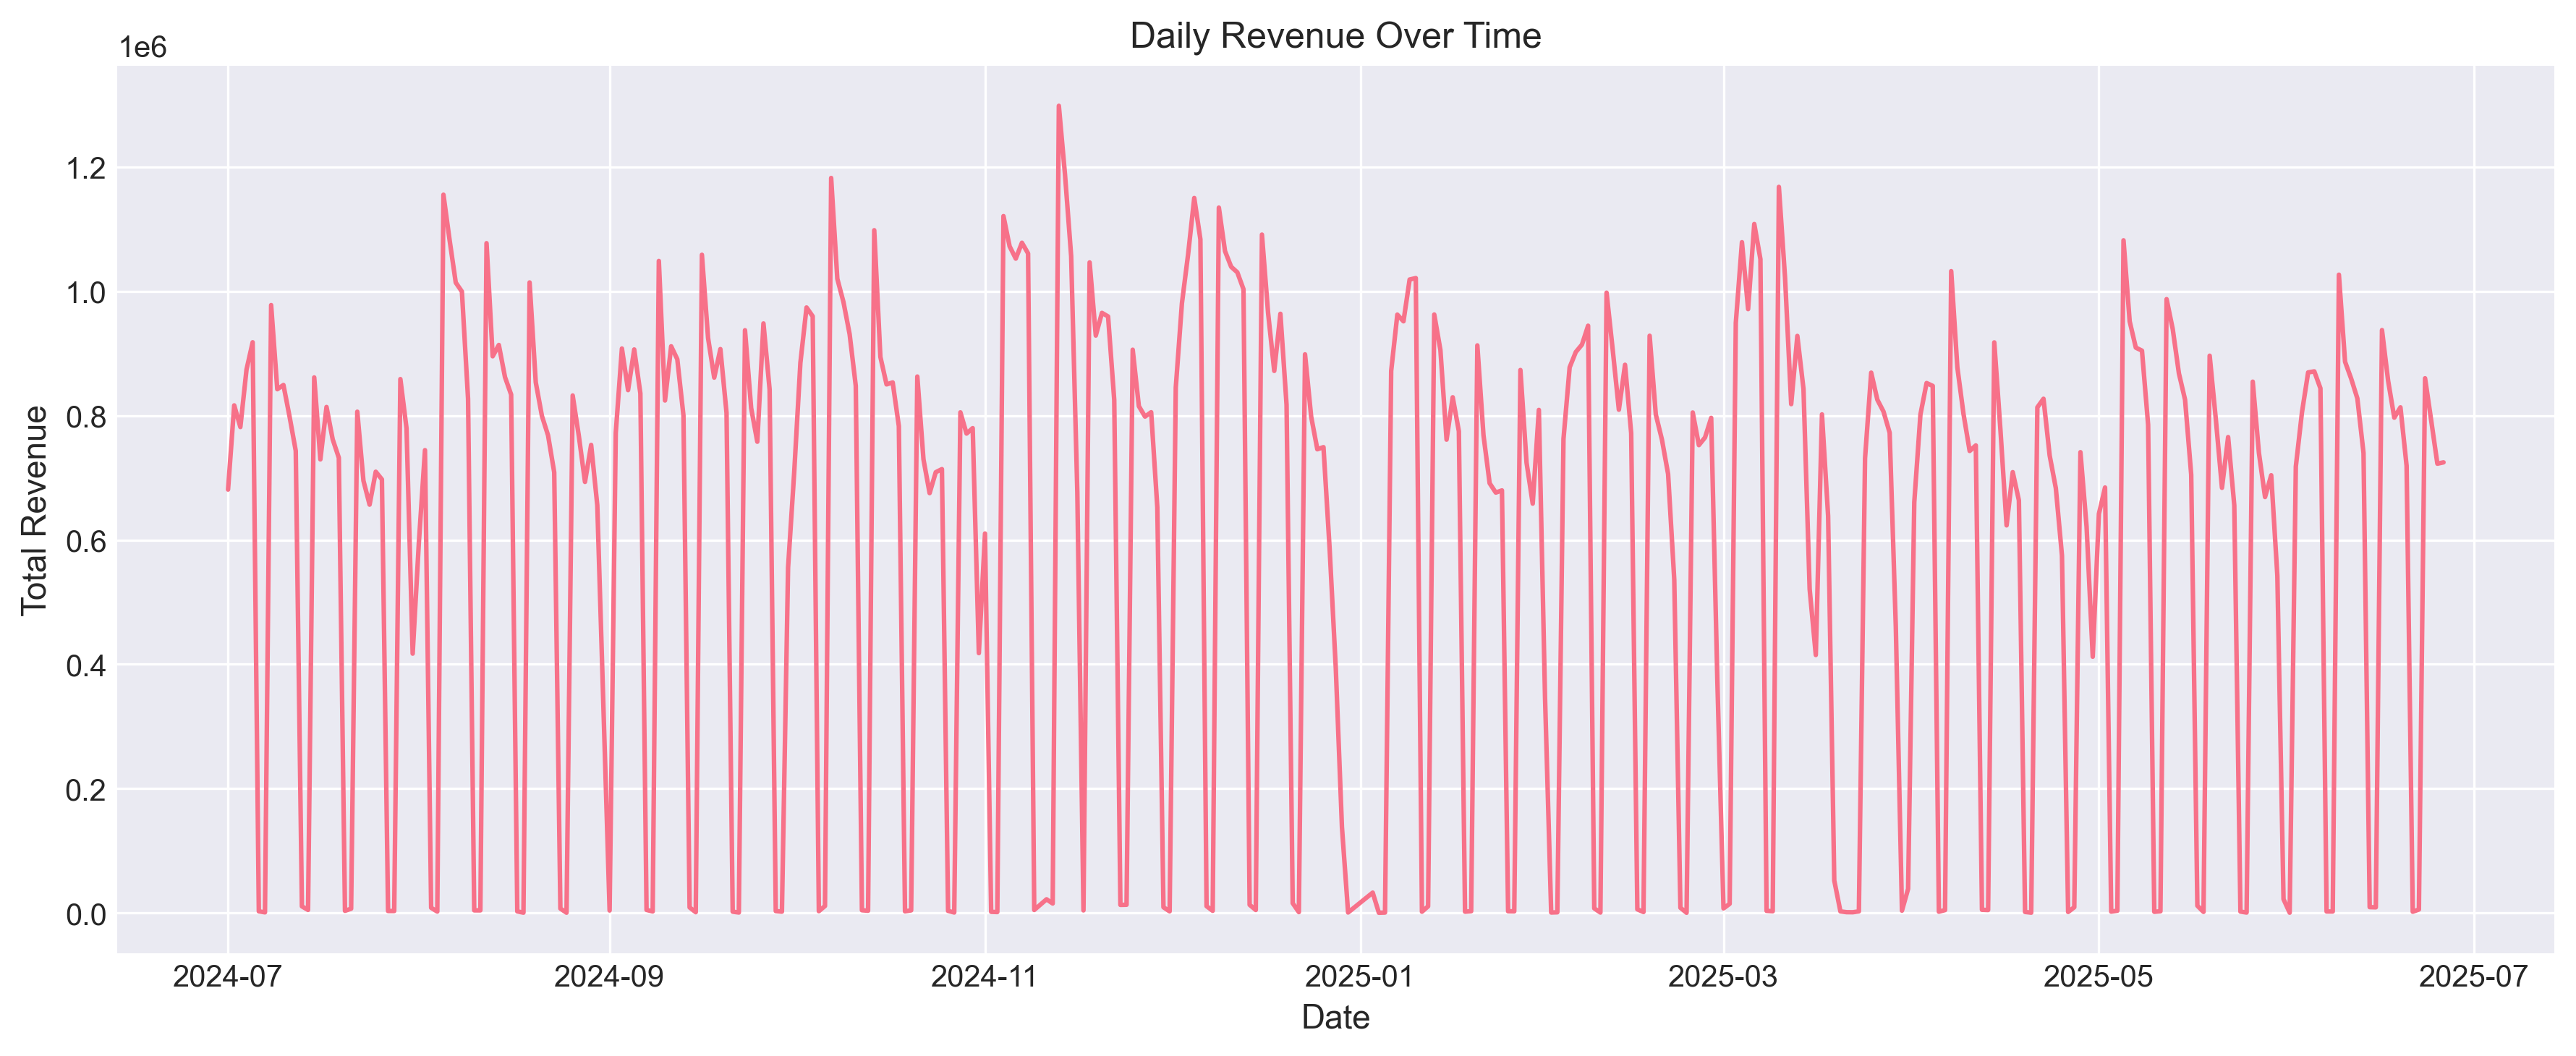

In [139]:
daily_revenue = data.groupby("ProcessDate")["Revenue"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(daily_revenue["ProcessDate"], daily_revenue["Revenue"])
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


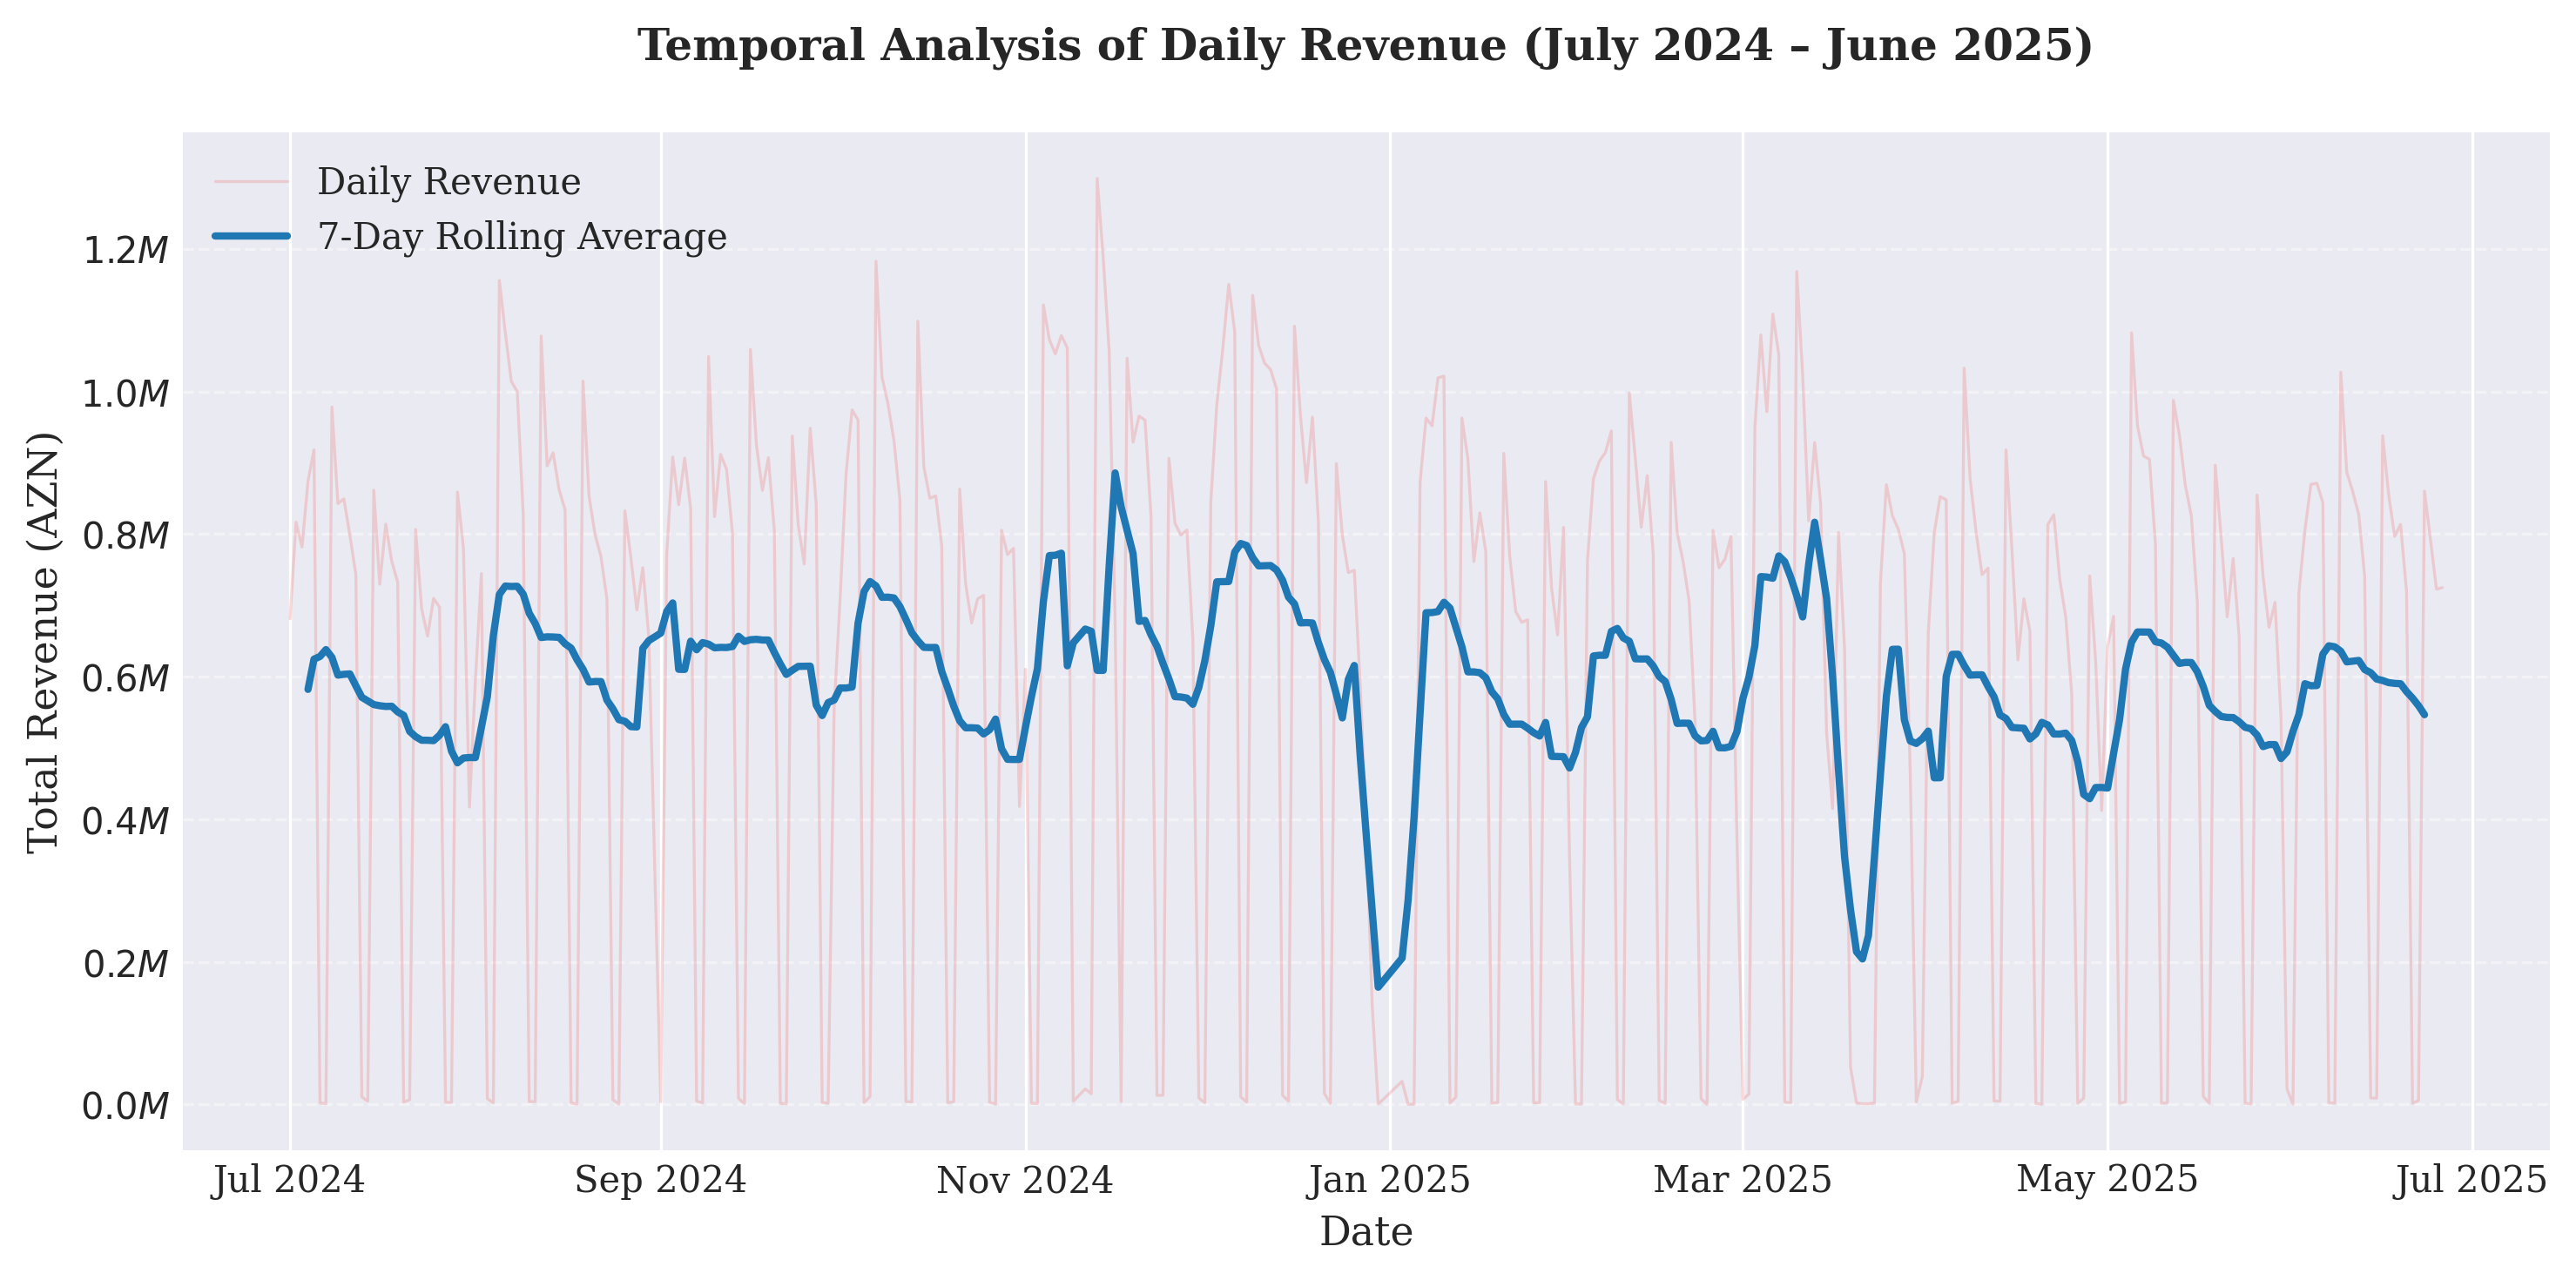

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Calculation
# window=7 smooths out the weekly cycle. 
# center=True aligns the average with the middle of the week for better temporal accuracy.
daily_revenue["Rolling_Avg"] = daily_revenue["Revenue"].rolling(window=7, center=True).mean()

# 2. Styling for Scientific Publication
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.spines.top': False,    # Remove unnecessary top border
    'axes.spines.right': False,  # Remove unnecessary right border
})

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Plot Raw Data: Faded so it doesn't distract from the trend
ax.plot(daily_revenue["ProcessDate"], daily_revenue["Revenue"], 
        color='lightcoral', alpha=0.3, linewidth=0.8, label='Daily Revenue')

# Plot Rolling Average: Bold and clear
ax.plot(daily_revenue["ProcessDate"], daily_revenue["Rolling_Avg"], 
        color='#1f77b4', linewidth=2, label='7-Day Rolling Average')

# 3. Professional Formatting
ax.set_title("Temporal Analysis of Daily Revenue (July 2024 – June 2025)", fontweight='bold', pad=20)
ax.set_xlabel("Date")
ax.set_ylabel("Total Revenue (AZN)")

# Format Y-axis to Millions for better readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M$'))

# Clean Date Formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Add a subtle grid for the Y-axis only to help value estimation
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('scientific_revenue_plot.png')

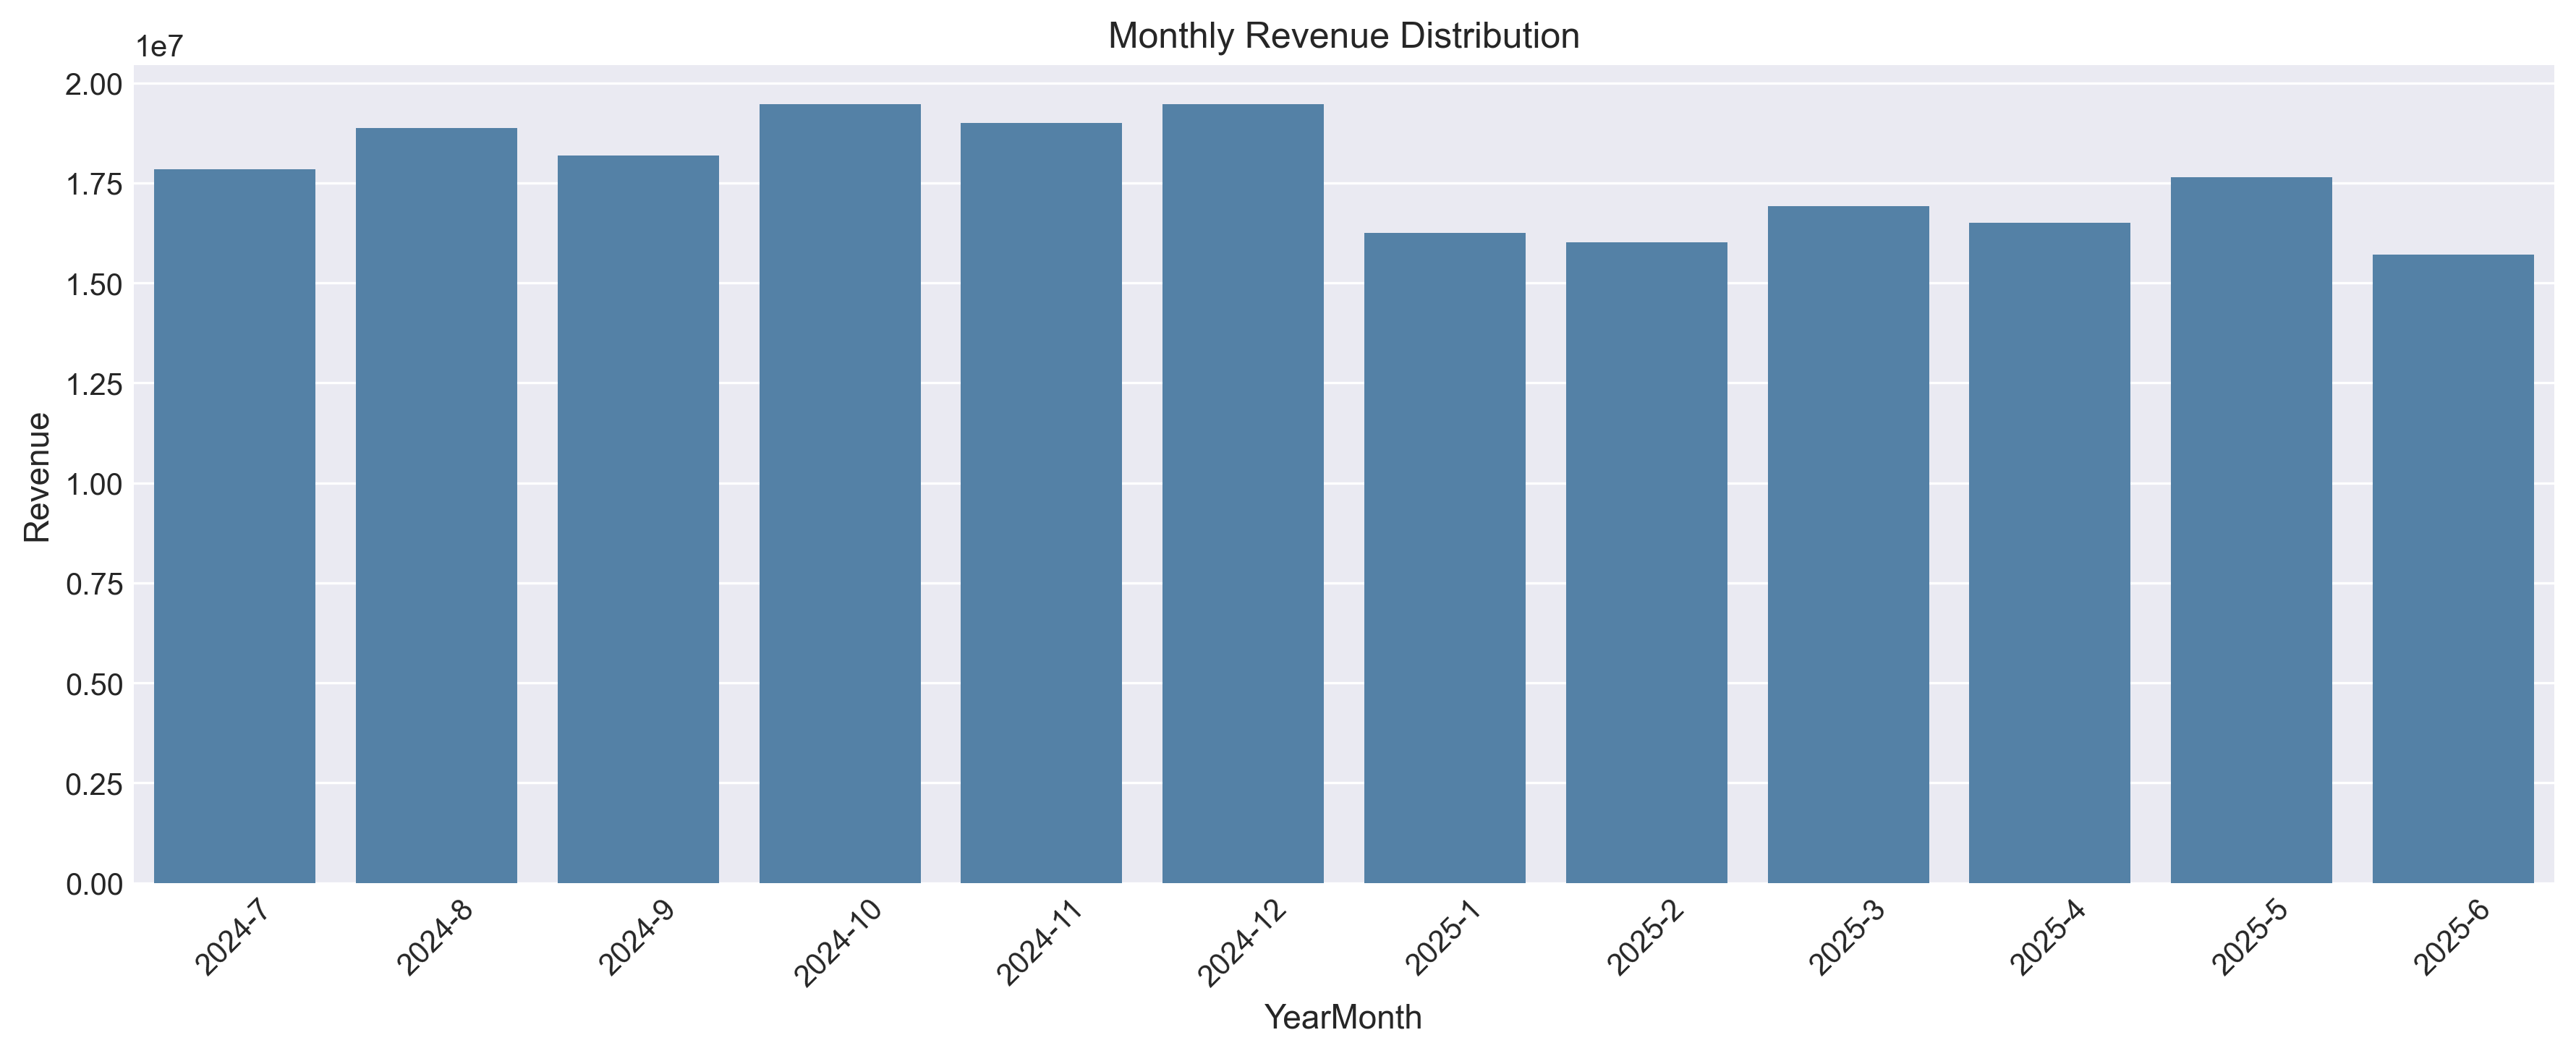

In [140]:
monthly_revenue = (
    data.groupby(["Year", "Month"])["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["YearMonth"] = (
    monthly_revenue["Year"].astype(str) + "-" +
    monthly_revenue["Month"].astype(str)
)

plt.figure(figsize=(12,5))
sns.barplot(
    data=monthly_revenue,
    x="YearMonth",
    y="Revenue",
    color="steelblue"
)
plt.xticks(rotation=45)
plt.title("Monthly Revenue Distribution")
plt.tight_layout()
plt.show()


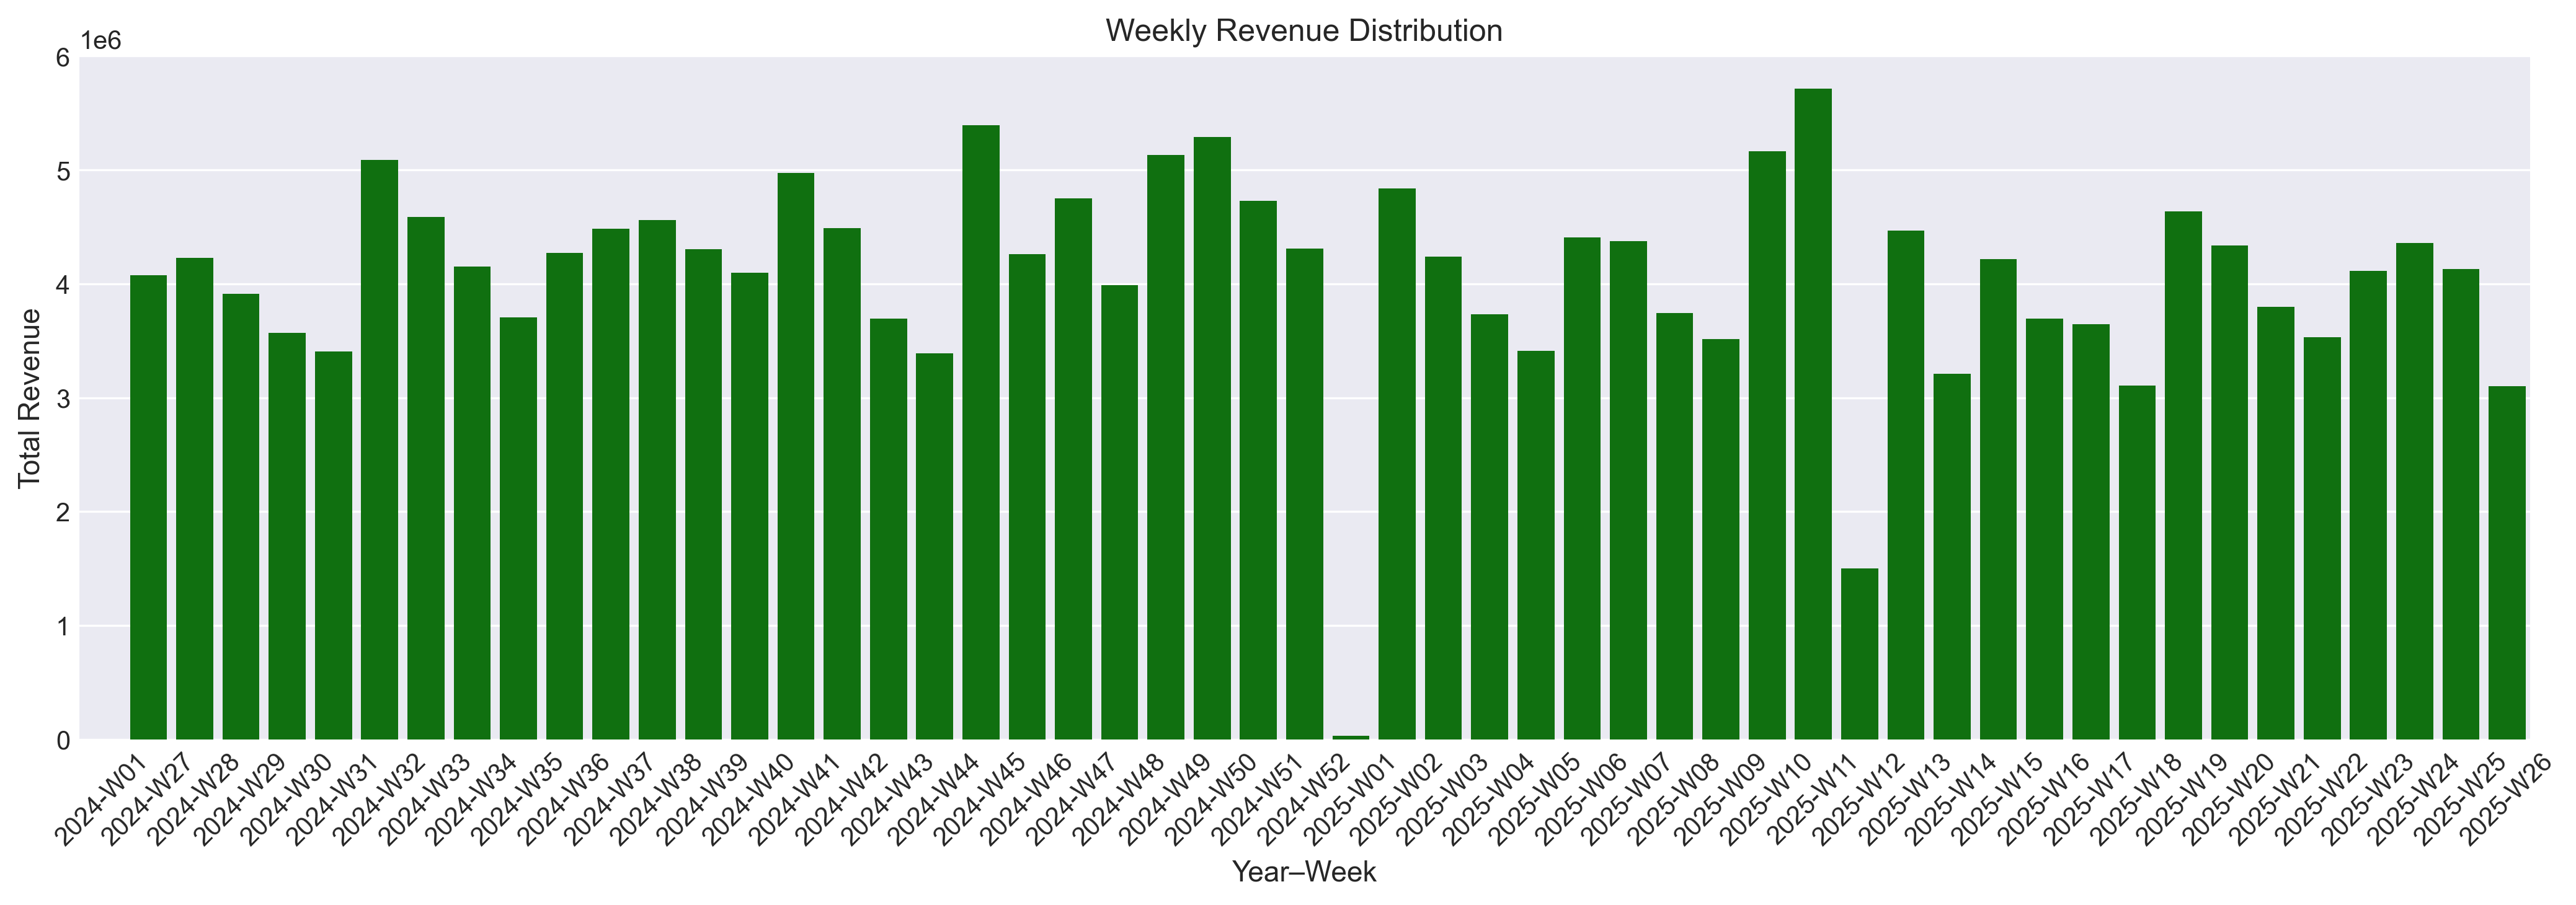

In [141]:
weekly_revenue = (
    data.groupby(["Year", "WeekOfYear"])["Revenue"]
    .sum()
    .reset_index()
)

# Create proper Year-Week label
weekly_revenue["YearWeek"] = (
    weekly_revenue["Year"].astype(str) + "-W" +
    weekly_revenue["WeekOfYear"].astype(str).str.zfill(2)
)

plt.figure(figsize=(14,5))
sns.barplot(
    data=weekly_revenue,
    x="YearWeek",
    y="Revenue",
    color="green"
)

plt.xticks(rotation=45)
plt.title("Weekly Revenue Distribution")
plt.xlabel("Year–Week")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


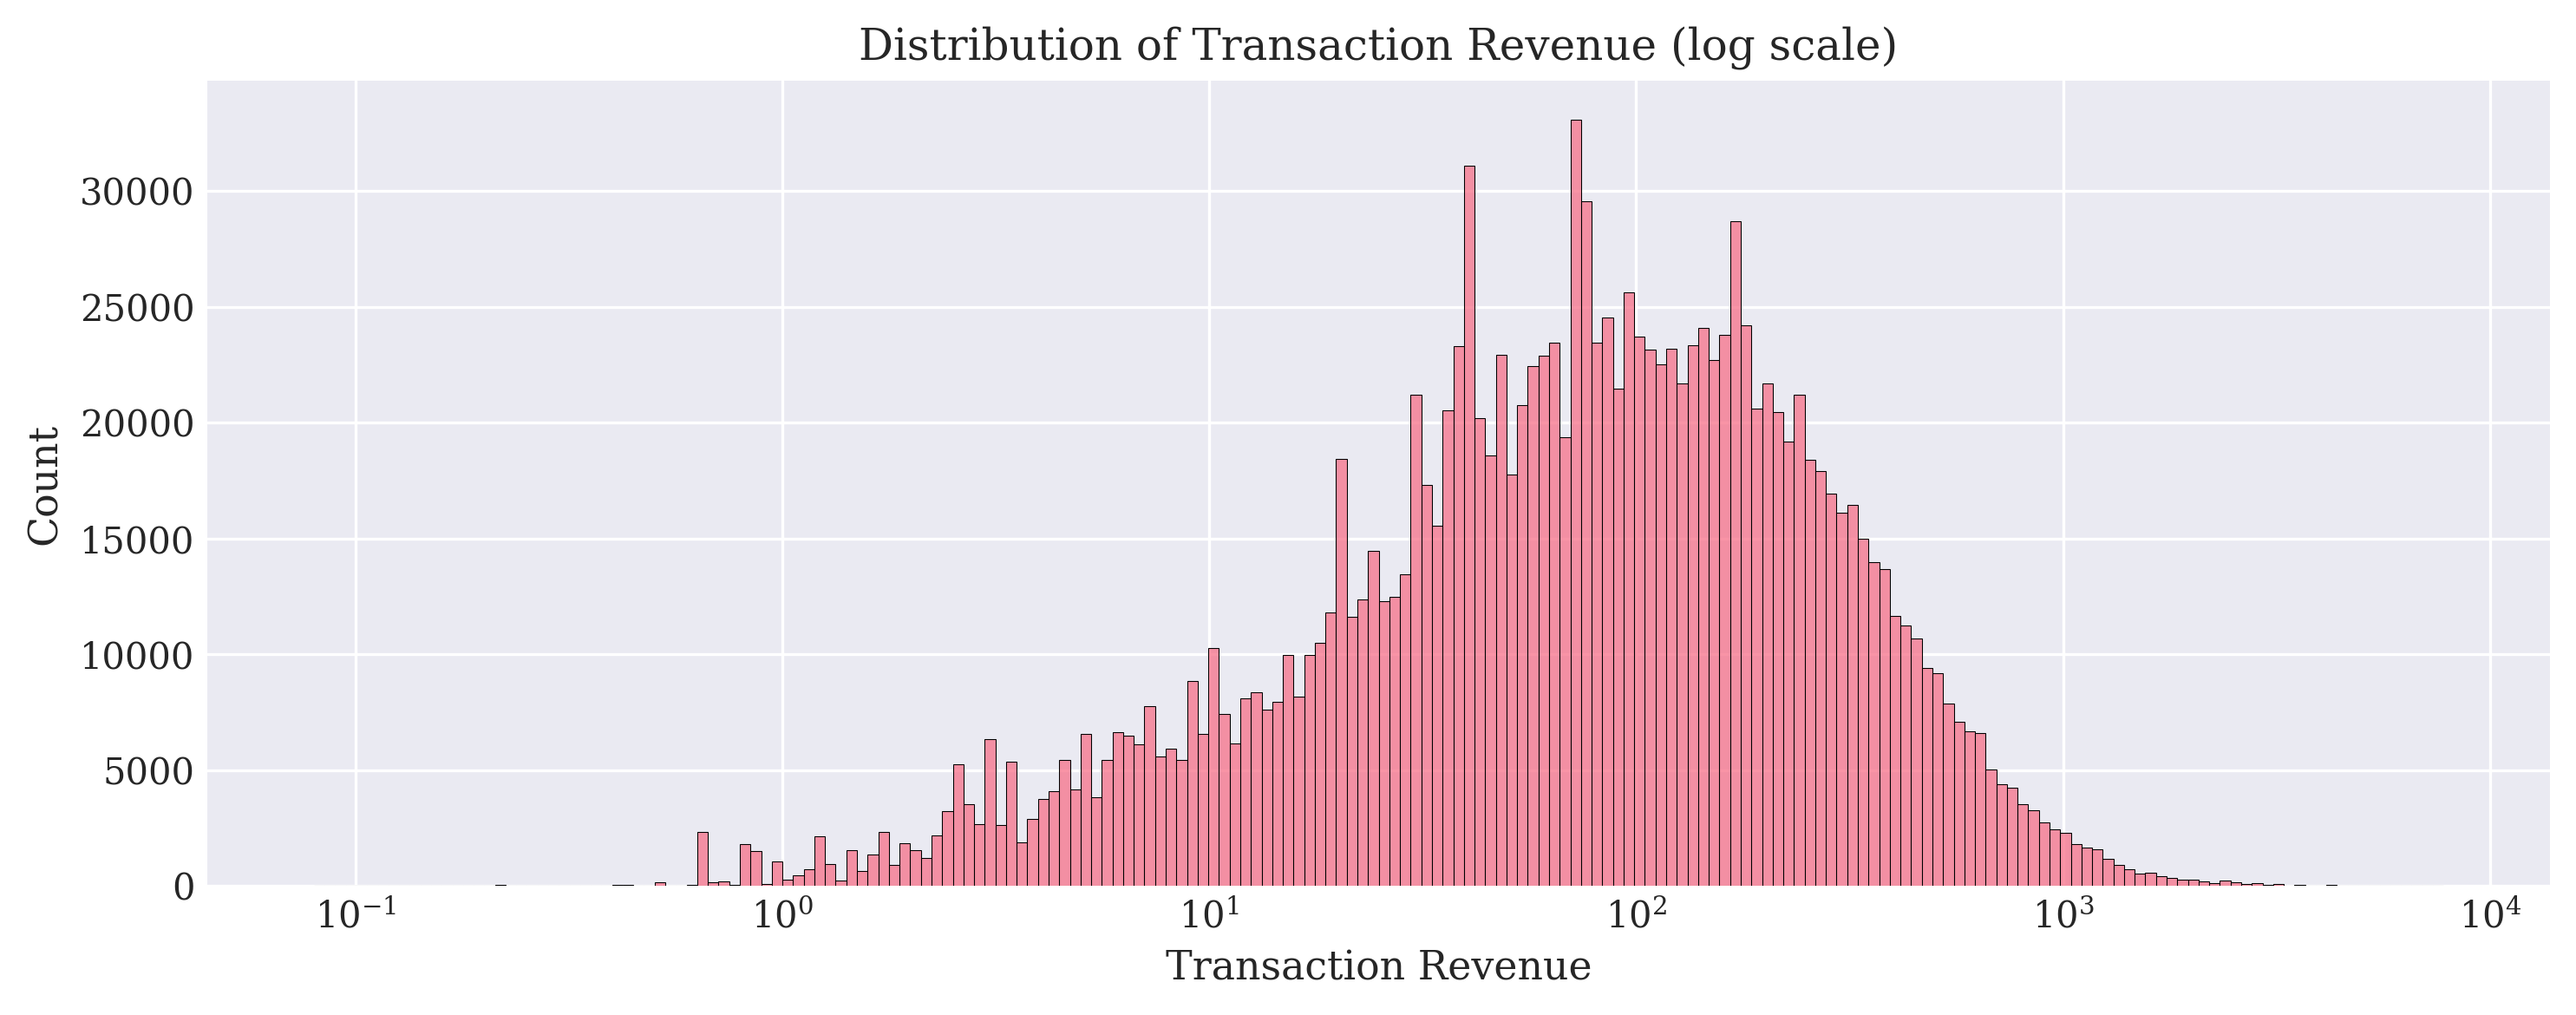

In [155]:
basket_revenue = data.groupby("SaleId")["Revenue"].sum()

plt.figure(figsize=(10,4))
sns.histplot(
    basket_revenue,
    bins=200,
    log_scale=True
)
plt.title("Distribution of Transaction Revenue (log scale)")
plt.xlabel("Transaction Revenue")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


IDK HOW TO INTERPRET THIS

THE ONE BELOW EITHER

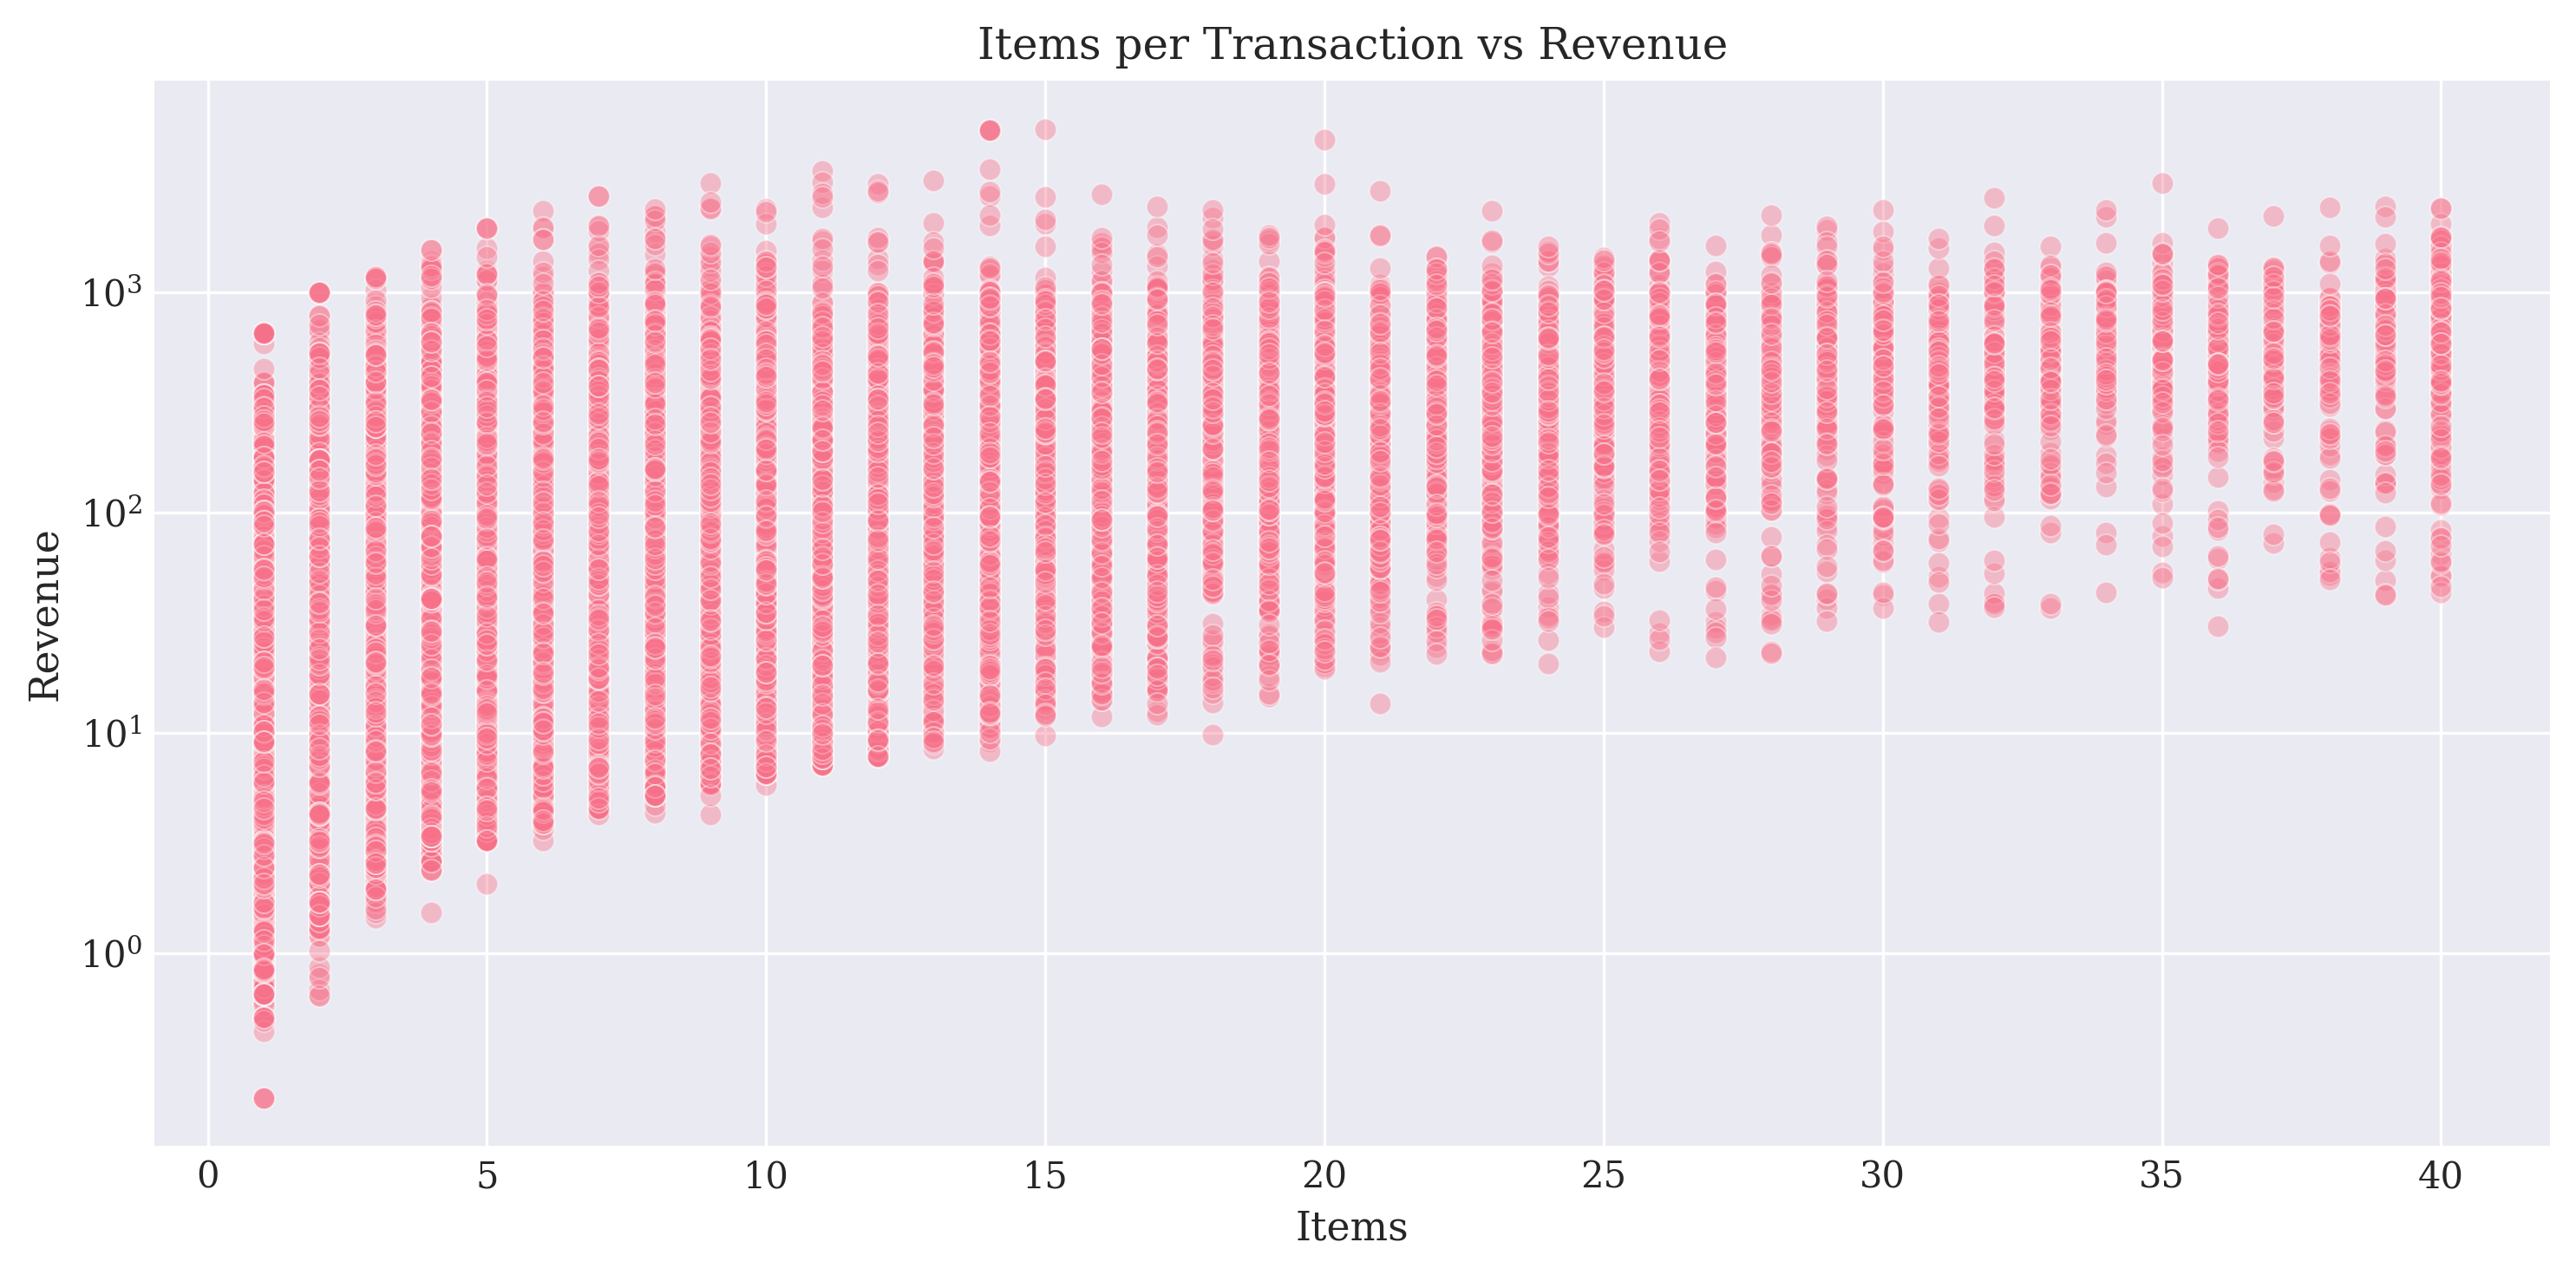

In [157]:
items_per_transaction = data.groupby("SaleId").size()
transaction_df = pd.DataFrame({
    "Items": items_per_transaction,
    "Revenue": basket_revenue
})

plt.figure(figsize=(10,5))
sns.scatterplot(
    data=transaction_df.sample(50000),
    x="Items",
    y="Revenue",
    alpha=0.4
)
plt.yscale("log")
plt.title("Items per Transaction vs Revenue")
plt.tight_layout()
plt.show()


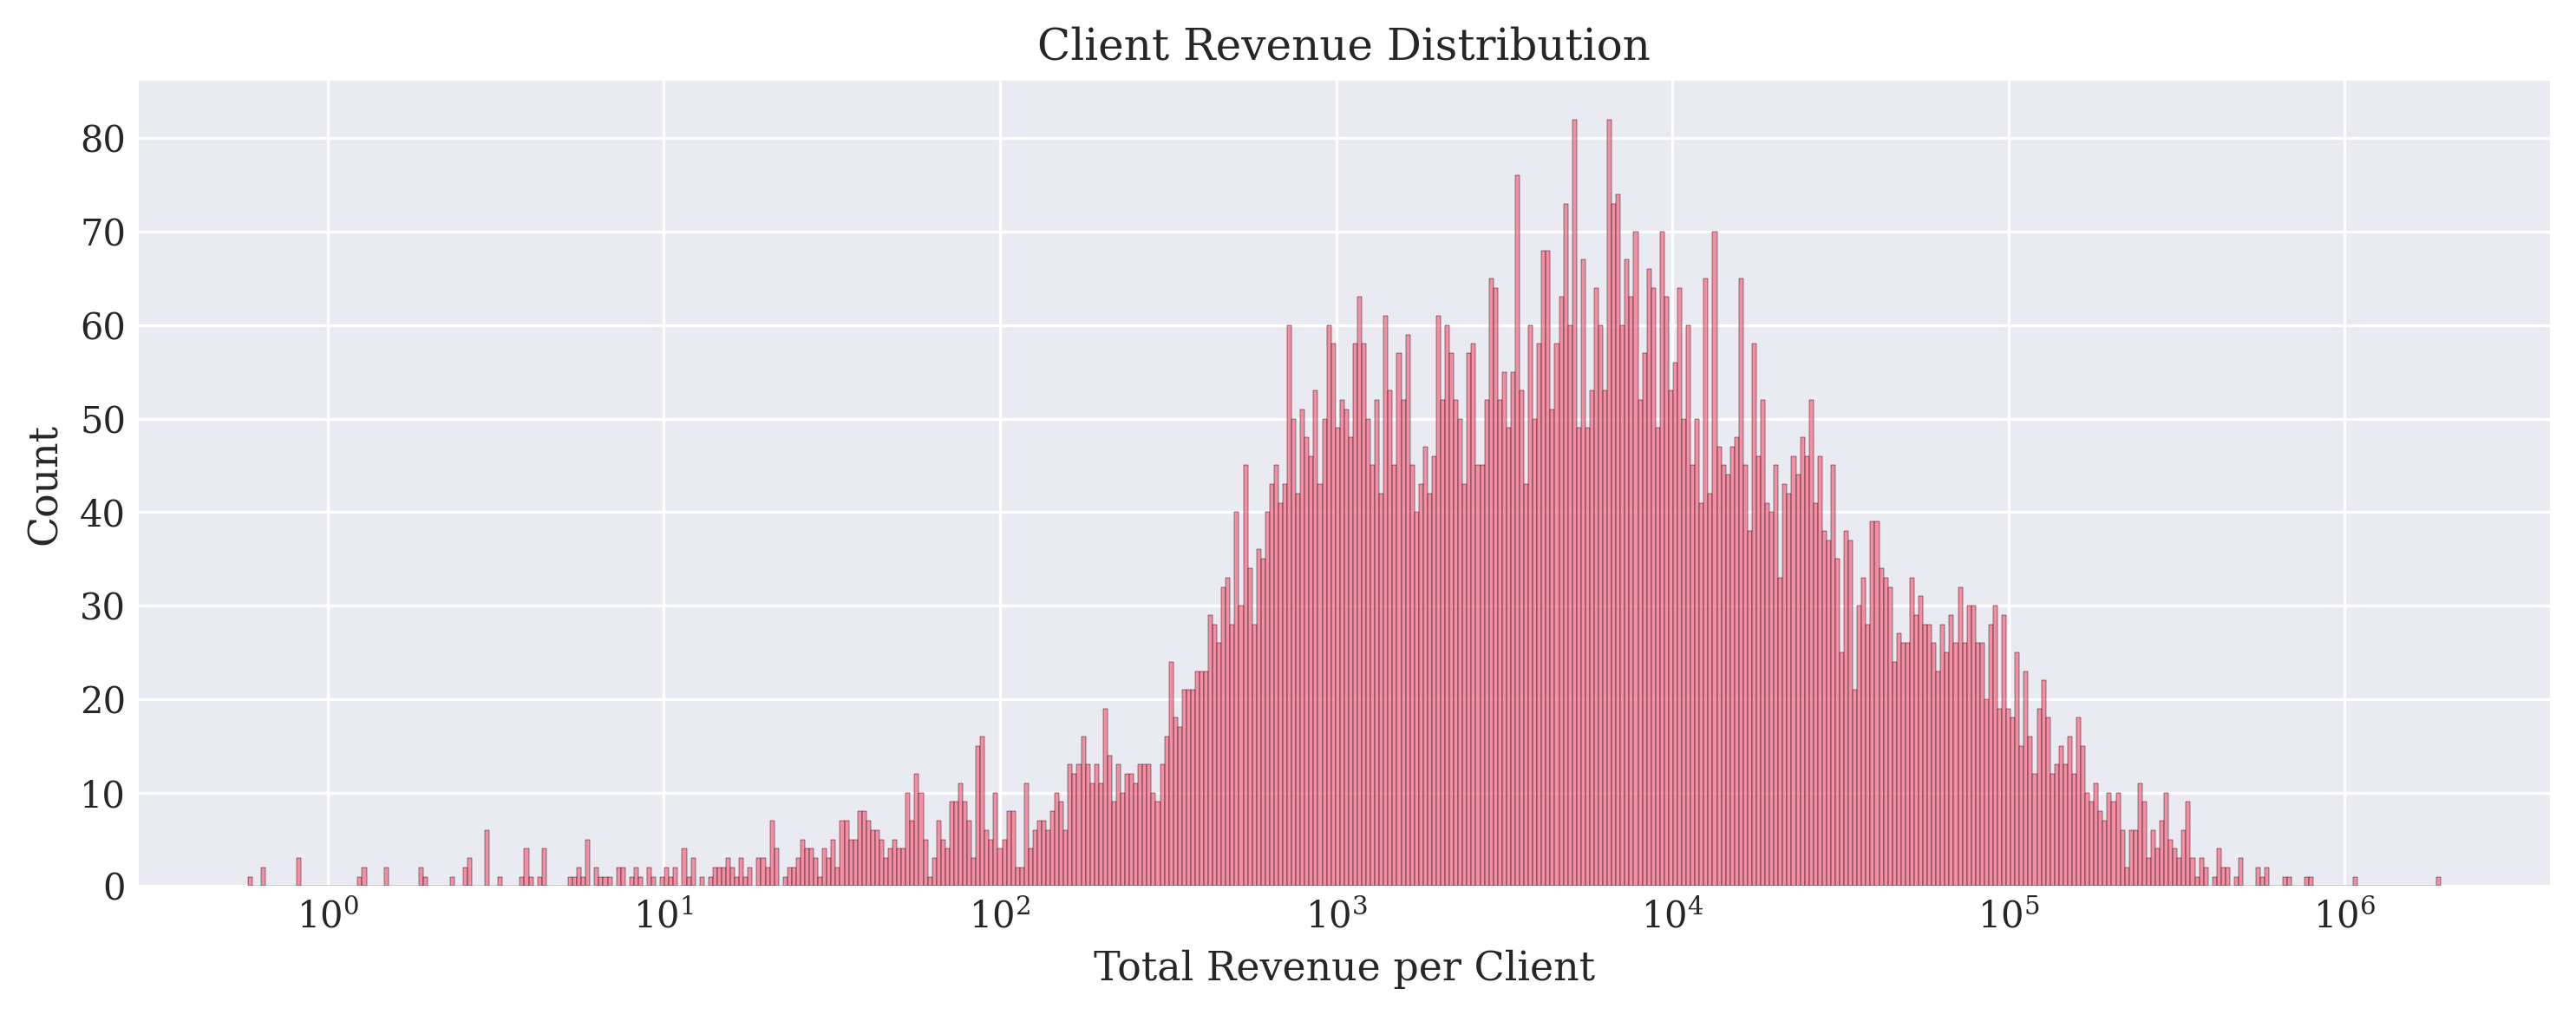

In [160]:
client_revenue = (
    data.groupby("ClientId")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,4))
sns.histplot(client_revenue, bins=500, log_scale=True)
plt.title("Client Revenue Distribution")
plt.xlabel("Total Revenue per Client")
plt.tight_layout()
plt.show()


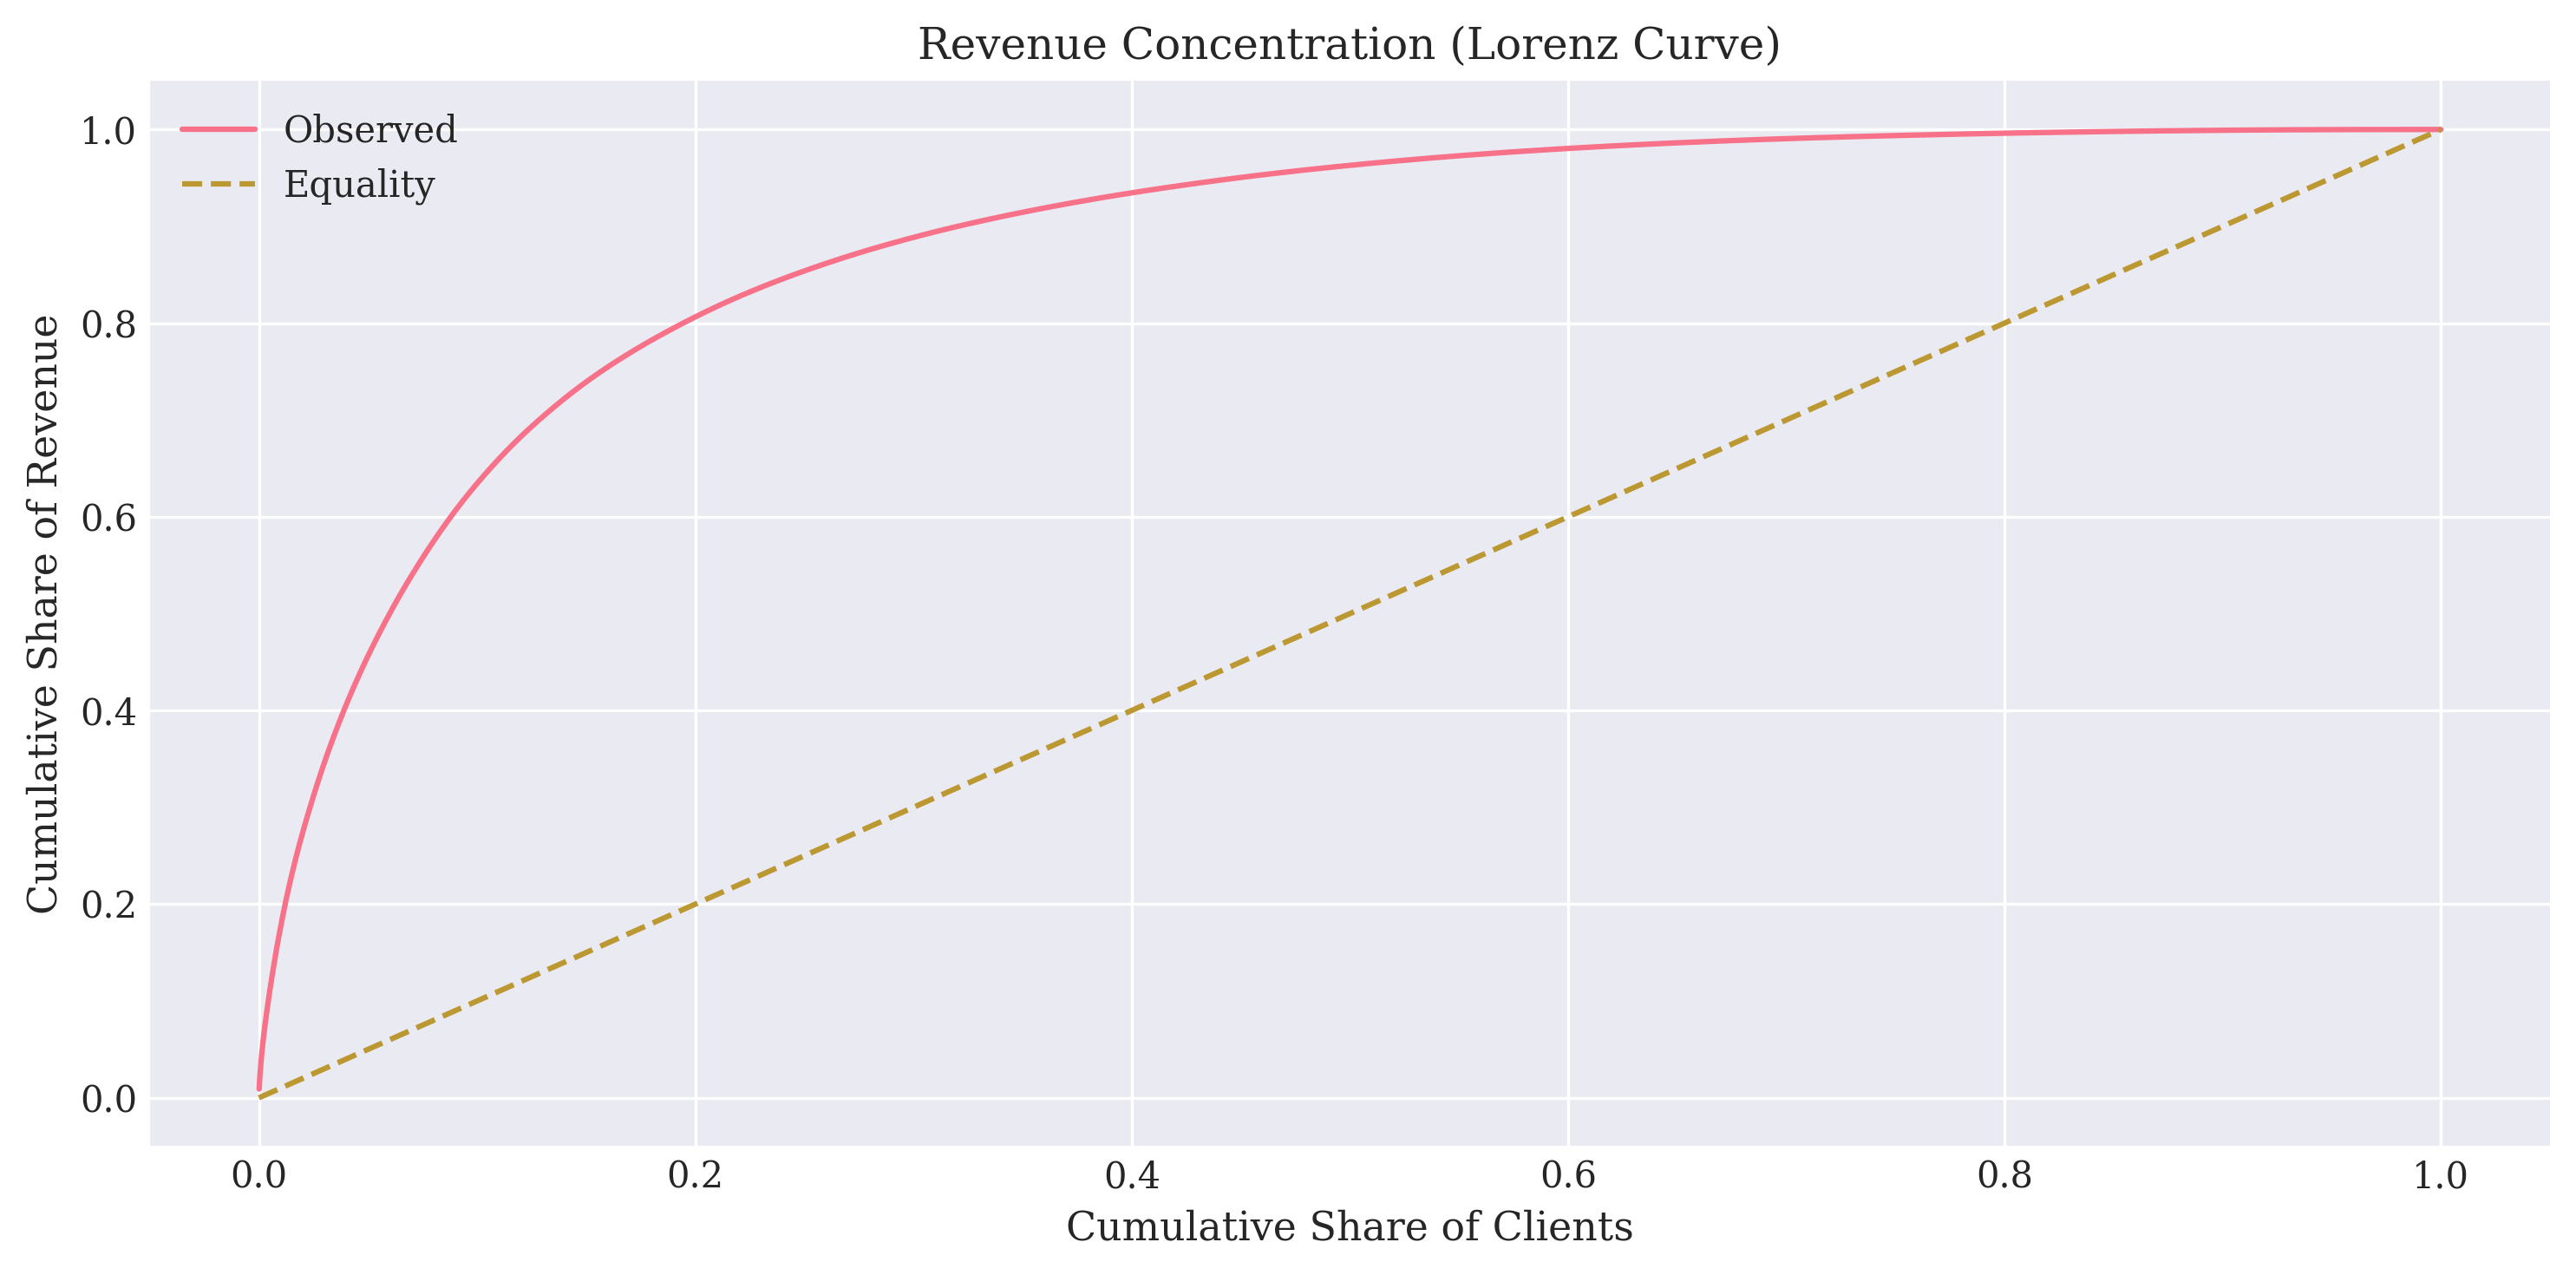

In [174]:
cum_rev = client_revenue.cumsum()
cum_rev_pct = cum_rev / cum_rev.iloc[-1]
clients_pct = np.arange(1, len(cum_rev_pct)+1) / len(cum_rev_pct)

plt.figure(figsize=(10,5))
plt.plot(clients_pct, cum_rev_pct, label="Observed")
plt.plot([0,1], [0,1], linestyle="--", label="Equality")
plt.xlabel("Cumulative Share of Clients")
plt.ylabel("Cumulative Share of Revenue")
plt.title("Revenue Concentration (Lorenz Curve)")
plt.legend()
plt.tight_layout()
plt.show()


1. Reading the 80/20 Rule (Pareto Principle)
You can use this graph to find exactly how much power your "whales" have. Look at the x-axis at the 0.2 mark (the top 20% of clients):

Follow the line up from 0.2 on the X-axis to the pink curve.

The corresponding value on the Y-axis appears to be around 0.8 (80%) .

Interpretation: This confirms a classic Pareto distribution. Roughly 20% of your clients are generating 80% of your total revenue.




2. High Dependency Risk
The very steep "climb" at the start of the graph (near 0.0 on the X-axis) shows that your very top clients (the top 1–5%) are responsible for a massive chunk of your wealth (nearly 40-50% based on the curve's trajectory).

Scientific Takeaway: Your business has high concentration risk . Losing just a few of those "top-tier" clients would have a significantly larger impact than losing thousands of "bottom-tier" clients.

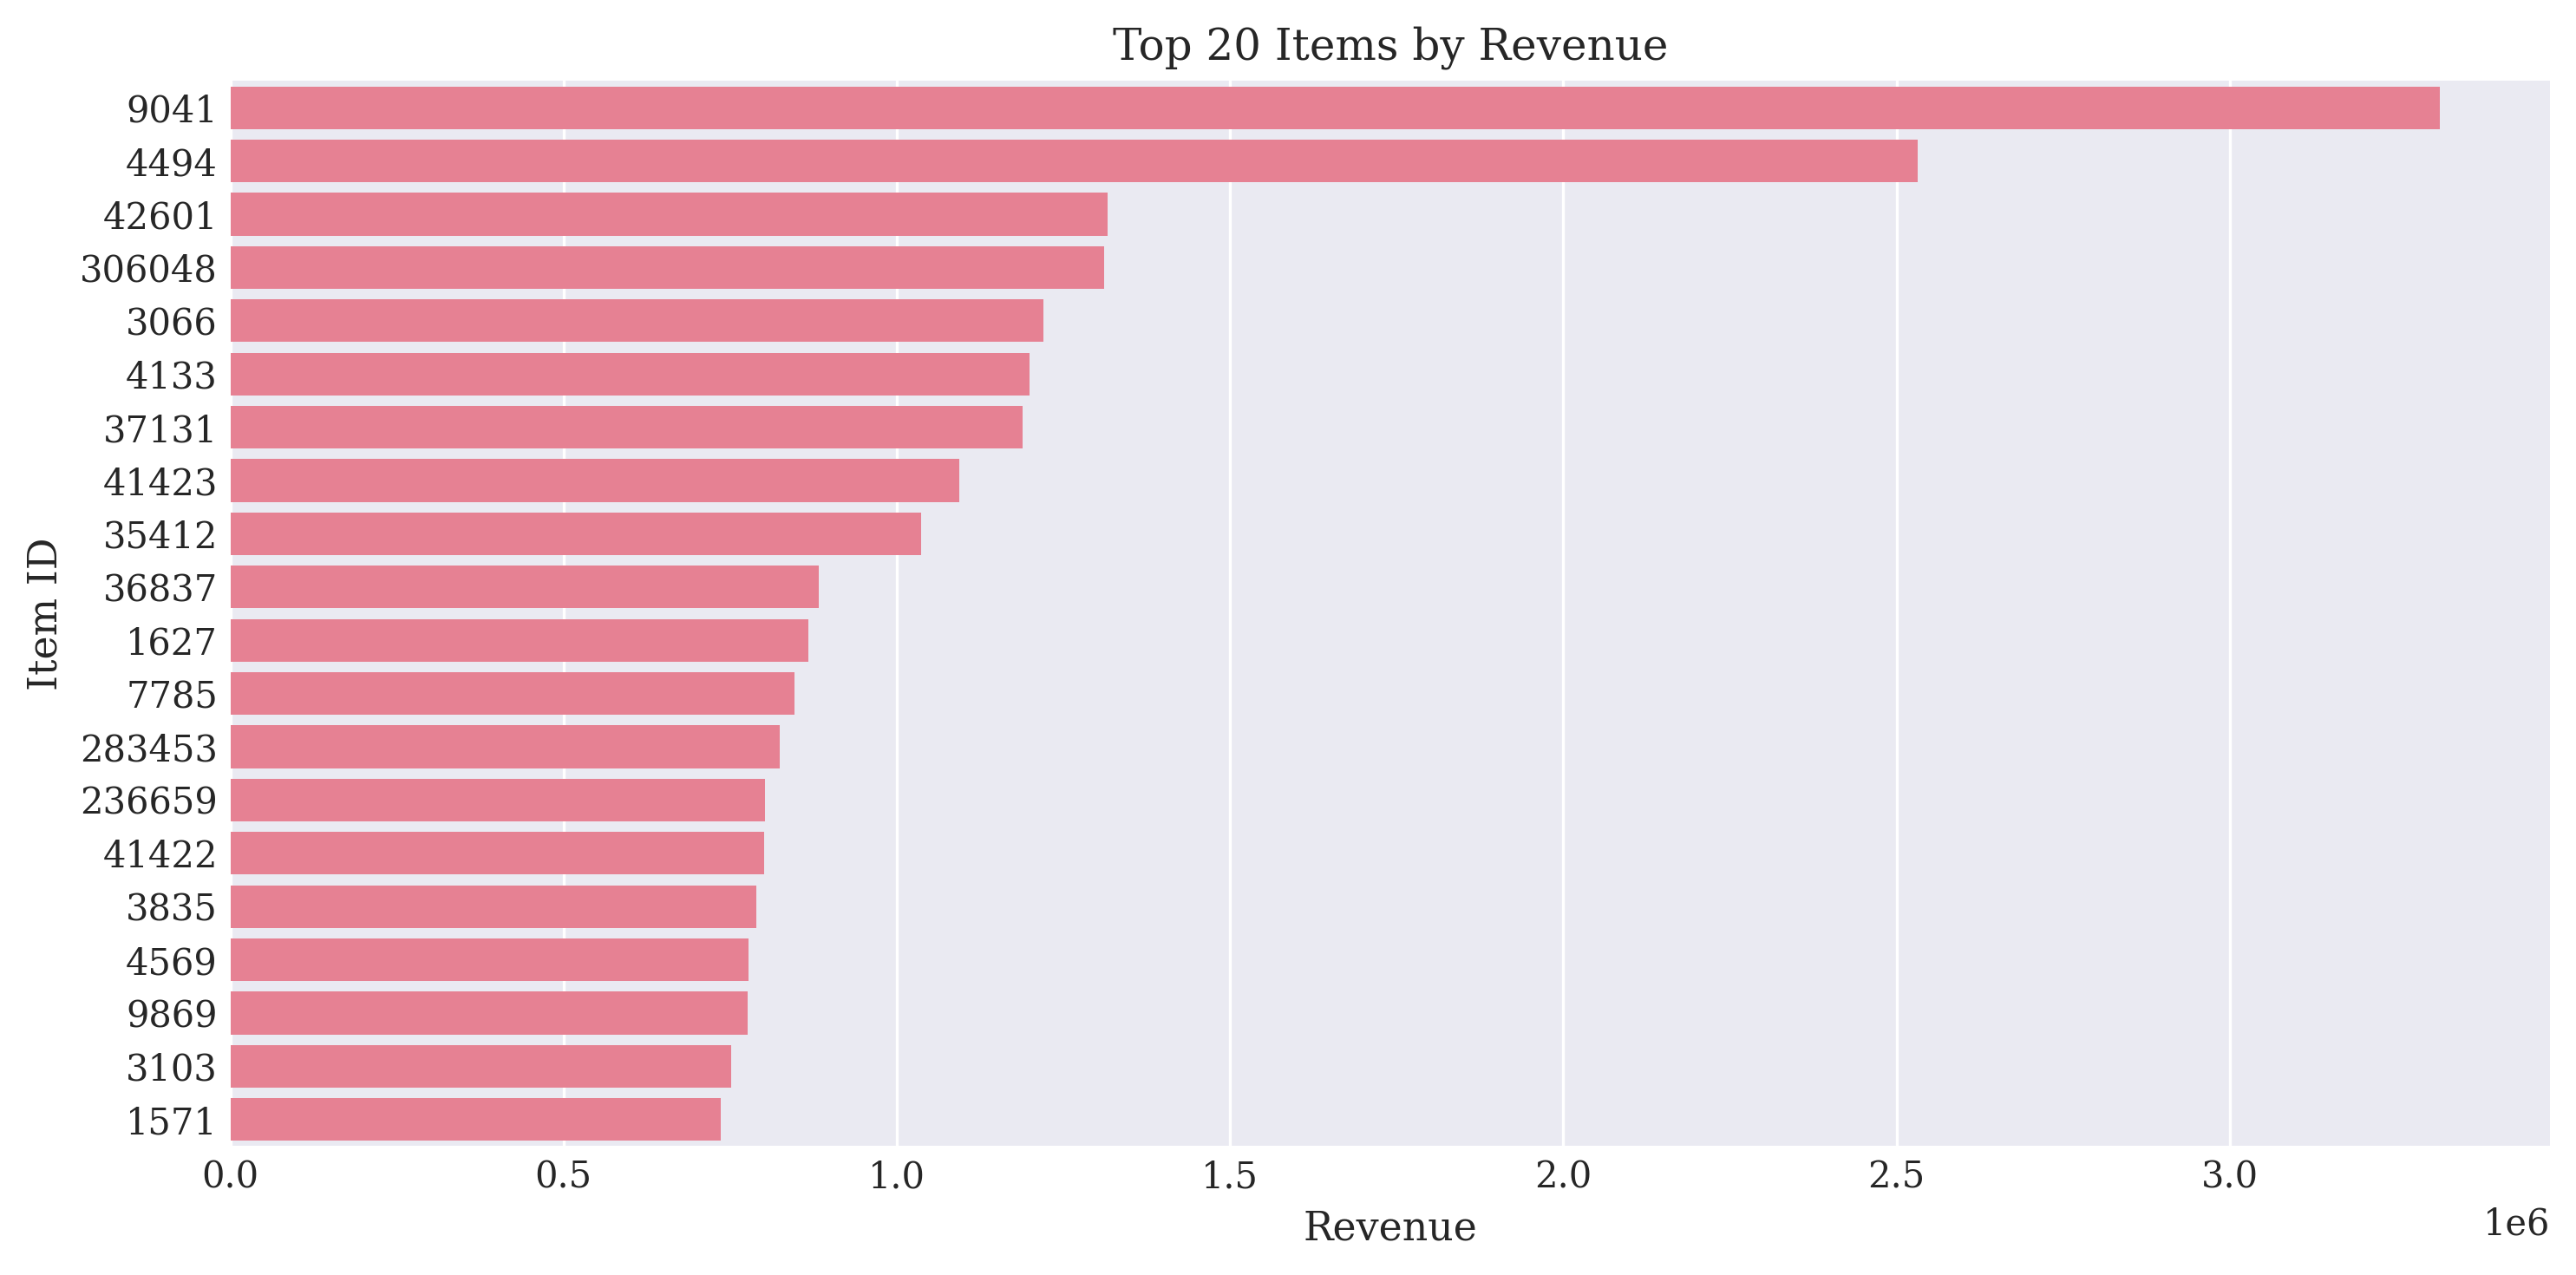

In [176]:
top_items = (
    data.groupby("ItemId")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10,5))
sns.barplot(
    y=top_items.index.astype(str),
    x=top_items.values
)
plt.title("Top 20 Items by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Item ID")
plt.tight_layout()
plt.show()


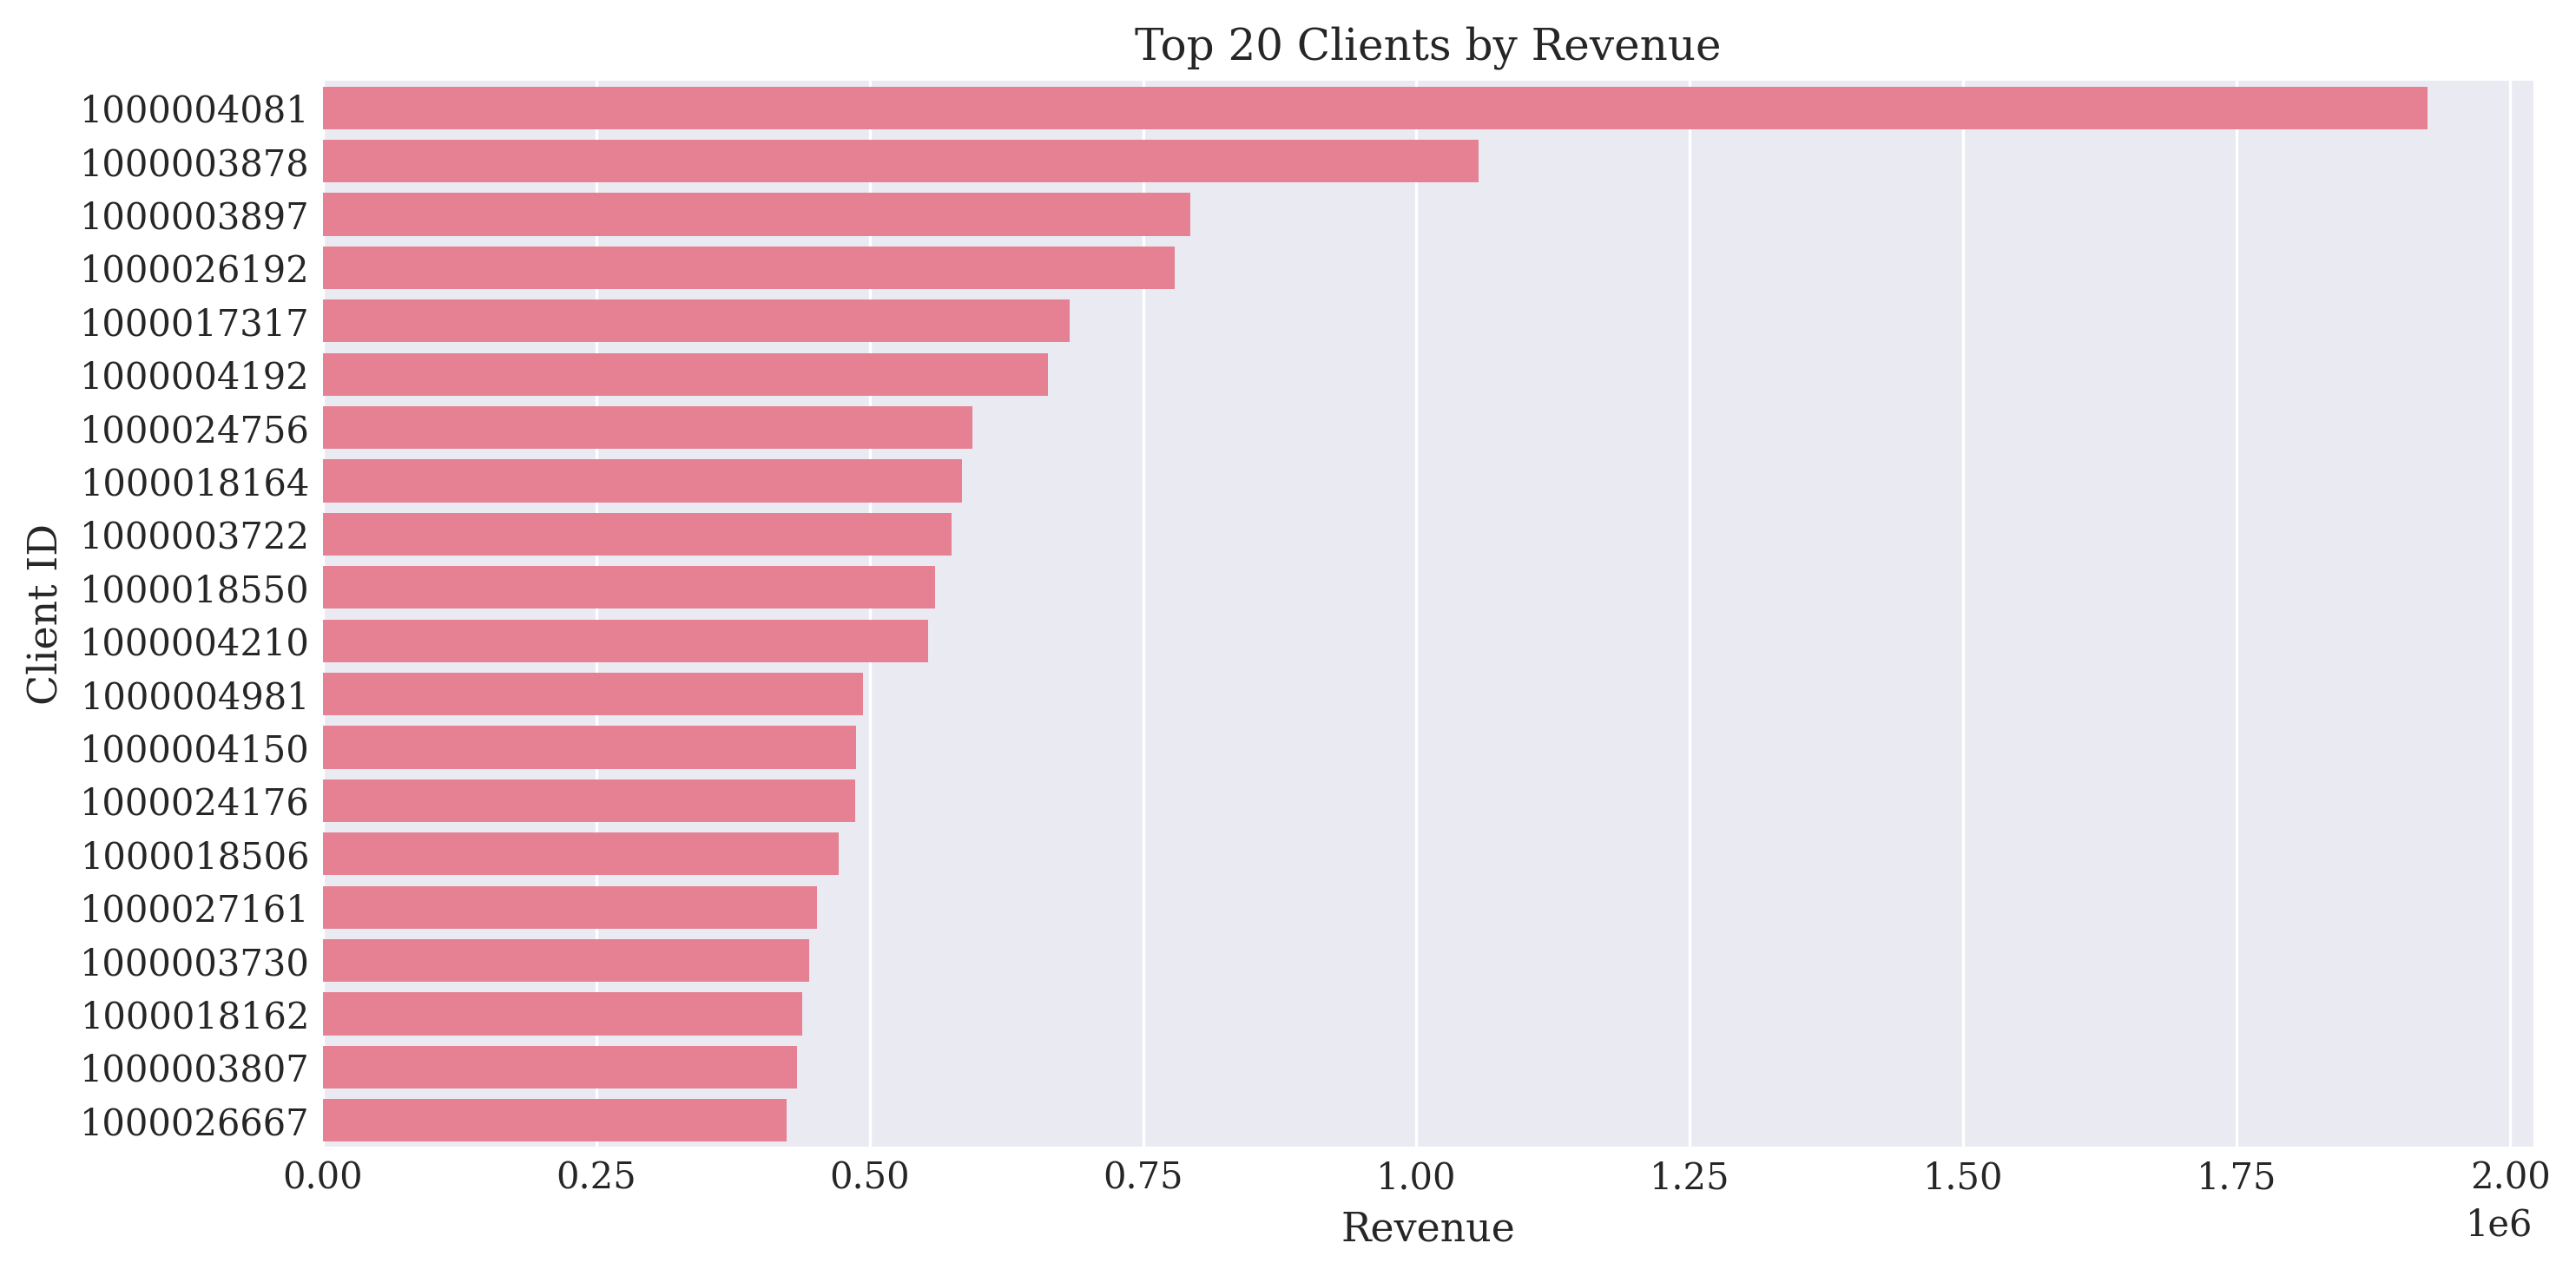

In [184]:
top_items = (
    data.groupby("ClientId")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10,5))
sns.barplot(
    y=top_items.index.astype(str),
    x=top_items.values
)
plt.title("Top 20 Clients by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Client ID")
plt.tight_layout()
plt.show()
